# 10. 의심 케이스 가격·물량 효과 분해

## 목적
우회 의심 케이스(flow2 증가)의 수입 금액 증가가
**물량 증가** 때문인지 **단가 상승** 때문인지 분해한다.

상품 가격이 전반적으로 올랐다면 flow2 금액 증가는 우회 신호가 아닐 수 있다.

## 방법
- `circumvention_suspects.csv`의 `is_suspect=True` 조합(source_row_id × intermediary_iso2)을
  `customs_flow0_flow2_raw.csv`에 조인
- 월별 합산 후 단가 = `imp_dlr / imp_wgt` 계산
- before/after 기준 금액·중량·단가 변화 분해
- 결과 유형 분류: 물량 증가형 / 가격 상승형 / 혼합형 / 판정 보류

## 입력
- `data/interim/circumvention_suspects.csv`
- `data/interim/customs_flow0_flow2_raw.csv`

## 출력
- `data/interim/price_volume_decomposition.csv`

## 노트
- flow_corrected 재계산 불필요: suspects 조합이 이미 09의 corrected flow 기준
- Comtrade World→World 세계 단가 수집(구 10번 목적)은 빈 응답 문제로 deprecated

## 0. 라이브러리 & 설정

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = ["AppleGothic", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR       = Path("../data/interim")
SUSPECTS_PATH  = DATA_DIR / "circumvention_suspects.csv"
CUSTOMS_PATH   = DATA_DIR / "customs_flow0_flow2_raw.csv"
OUTPUT_PATH    = DATA_DIR / "price_volume_decomposition.csv"

# 중량 0 비율이 이 값 이상이면 단가 판정 보류
ZERO_WGT_THRESHOLD = 0.5

## 1. 데이터 로드

In [2]:
suspects = pd.read_csv(SUSPECTS_PATH)
customs  = pd.read_csv(CUSTOMS_PATH)

print("suspects shape:", suspects.shape)
print("customs  shape:", customs.shape)
print()
print("is_suspect 분포:")
print(suspects["is_suspect"].value_counts())

suspects shape: (3652, 14)
customs  shape: (141907, 17)

is_suspect 분포:
is_suspect
False    3609
True       43
Name: count, dtype: int64


In [3]:
# trade_date: YYYY-MM 문자열 → Period
customs["trade_date"] = pd.to_datetime(
    customs["trade_date"], format="%Y-%m"
).dt.to_period("M")

# start_date 파싱
customs["start_date"]   = pd.to_datetime(customs["start_date"])
customs["start_period"] = customs["start_date"].dt.to_period("M")

# before/after 레이블
customs["period_label"] = (customs["trade_date"] >= customs["start_period"]).map(
    {True: "after", False: "before"}
)

# null country_iso2 제거
customs = customs[customs["country_iso2"].notna()].copy()

print("전처리 후 customs shape:", customs.shape)

전처리 후 customs shape: (141878, 19)


## 2. 의심 조합 추출 & 조인

`circumvention_suspects.csv`의 `is_suspect=True` 조합(source_row_id × intermediary_iso2)을
customs flow2 데이터에 조인한다.

In [4]:
targets = suspects[suspects["is_suspect"]].copy()
print(f"의심 조합: {len(targets)}건 / {targets['source_row_id'].nunique()}개 사건")

# flow 필터 없이 전체 customs에서 (source_row_id, country_iso2) 기준 조인
# targets 자체가 09의 flow_corrected==2 결과이므로 별도 flow 필터 불필요
customs_dedup = (
    customs
    .drop_duplicates(subset=["source_row_id", "trade_date", "country_iso2", "hs_code"])
    .copy()
)

# product_name_kr은 customs_dedup에도 있으므로 suspects 쪽에서 제외
df_case = customs_dedup.merge(
    targets[["source_row_id", "intermediary_iso2", "suspicion_score", "f0_pct", "f2_pct"]],
    left_on=["source_row_id", "country_iso2"],
    right_on=["source_row_id", "intermediary_iso2"],
    how="inner",
)

print(f"\n조인 후 행 수: {len(df_case):,}")
print(f"커버된 의심 조합: {df_case.groupby(['source_row_id','intermediary_iso2']).ngroups}건")

의심 조합: 43건 / 23개 사건

조인 후 행 수: 2,588
커버된 의심 조합: 43건


## 3. 월별 합산 & 단가 계산

In [5]:
# 월별 합산 (같은 월·국가에 여러 HS 하위 row 존재 → 먼저 합산)
monthly = (
    df_case
    .groupby(["source_row_id", "intermediary_iso2", "trade_date", "period_label",
              "product_name_kr", "suspicion_score"])
    .agg(
        imp_dlr=("imp_dlr", "sum"),
        imp_wgt=("imp_wgt", "sum"),
    )
    .reset_index()
)

# 단가: 중량 0이면 NaN
monthly["unit_price"] = (
    monthly["imp_dlr"] / monthly["imp_wgt"].replace(0, np.nan)
)

print("월별 집계 shape:", monthly.shape)
print(f"unit_price NaN 비율: {monthly['unit_price'].isna().mean()*100:.1f}%")

월별 집계 shape: (906, 9)
unit_price NaN 비율: 6.3%


## 4. Before/After 요약 — 금액·중량·단가

In [6]:
def summarize_period(grp: pd.DataFrame) -> pd.Series:
    """한 (source_row_id, intermediary, period_label) 그룹의 요약 통계 계산."""
    total_dlr = grp["imp_dlr"].sum()
    total_wgt = grp["imp_wgt"].sum()
    n_months  = grp["trade_date"].nunique()
    zero_wgt_rate = (grp["imp_wgt"] == 0).mean()

    return pd.Series({
        "avg_dlr":           total_dlr / n_months if n_months > 0 else np.nan,
        "avg_wgt":           total_wgt / n_months if n_months > 0 else np.nan,
        # weighted unit price: 총금액 / 총중량 (월별 단가 평균보다 안정적)
        "w_unit_price":      total_dlr / total_wgt if total_wgt > 0 else np.nan,
        "n_months":          n_months,
        "zero_wgt_rate":     zero_wgt_rate,
    })


group_cols = ["source_row_id", "intermediary_iso2", "product_name_kr",
              "suspicion_score", "period_label"]

period_summary = (
    monthly
    .groupby(group_cols)
    .apply(summarize_period)
    .reset_index()
)

print("period_summary shape:", period_summary.shape)
period_summary.head(6)

period_summary shape: (84, 10)


,source_row_id,intermediary_iso2,product_name_kr,suspicion_score,period_label,avg_dlr,avg_wgt,w_unit_price,n_months,zero_wgt_rate
0,1,JP,플로트판유리(2차재심),129.614562,after,2.673229e+06,3.970962e+05,6.731943,13.0,0.0
1,1,JP,플로트판유리(2차재심),129.614562,before,2.062445e+06,3.428395e+05,6.015774,12.0,0.0
2,1,TR,플로트판유리(2차재심),2248.812102,after,2.177068e+06,6.925662e+06,0.314348,2.0,0.0
3,1,TR,플로트판유리(2차재심),2248.812102,before,9.680967e+04,2.815650e+05,0.343827,6.0,0.0
4,3,JP,H형강,103.368864,after,2.462856e+06,4.398028e+06,0.559991,13.0,0.0
5,3,JP,H형강,103.368864,before,2.382590e+06,3.486840e+06,0.683309,12.0,0.0


In [7]:
# before/after pivot
index_cols = ["source_row_id", "intermediary_iso2", "product_name_kr", "suspicion_score"]

def pivot_metric(metric: str) -> pd.DataFrame:
    """지표 하나를 before/after로 pivot."""
    pv = (
        period_summary
        .pivot_table(index=index_cols, columns="period_label",
                     values=metric, fill_value=np.nan)
        .reset_index()
    )
    pv.columns.name = None
    for col in ["before", "after"]:
        if col not in pv.columns:
            pv[col] = np.nan
    pv = pv.rename(columns={"before": f"{metric}_before", "after": f"{metric}_after"})
    return pv


df_dlr   = pivot_metric("avg_dlr")
df_wgt   = pivot_metric("avg_wgt")
df_price = pivot_metric("w_unit_price")
df_nmth  = pivot_metric("n_months")
df_zwgt  = pivot_metric("zero_wgt_rate")

decomp = (
    df_dlr
    .merge(df_wgt,   on=index_cols)
    .merge(df_price, on=index_cols)
    .merge(df_nmth,  on=index_cols)
    .merge(df_zwgt,  on=index_cols)
)

# 변화율 계산
def pct_change(after, before):
    """before=0이면 after>0일 때 100% 클리핑."""
    denom = before.replace(0, np.nan)
    pct = (after - before) / denom * 100
    # before=0, after>0 → 100%로 처리
    mask = (before == 0) | (before.isna())
    pct[mask & (after > 0)] = 100.0
    pct[mask & (after == 0)] = 0.0
    return pct


decomp["dlr_pct"]   = pct_change(decomp["avg_dlr_after"],    decomp["avg_dlr_before"])
decomp["wgt_pct"]   = pct_change(decomp["avg_wgt_after"],    decomp["avg_wgt_before"])
decomp["price_pct"] = pct_change(decomp["w_unit_price_after"], decomp["w_unit_price_before"])

print("분해 결과 shape:", decomp.shape)
decomp[["source_row_id", "intermediary_iso2", "product_name_kr",
         "dlr_pct", "wgt_pct", "price_pct"]].head(10)

분해 결과 shape: (43, 17)


,source_row_id,intermediary_iso2,product_name_kr,dlr_pct,wgt_pct,price_pct
0,1,JP,플로트판유리(2차재심),29.614562,15.825694,11.904843
1,1,TR,플로트판유리(2차재심),2148.812102,2359.702555,-8.573819
2,3,JP,H형강,3.368864,26.132219,-18.047217
3,3,VN,H형강,100.000000,100.000000,100.000000
4,5,GB,초산에틸(2차재심),113.060333,139.257111,-10.949216
5,8,CL,침엽수 합판,61.710824,51.395353,6.813598
6,8,MY,침엽수 합판,15.963129,27.445097,-9.009345
7,8,VN,침엽수 합판,15.535222,23.072920,-6.124579
8,10,MX,부틸글리콜에테르,100.000000,100.000000,100.000000
9,10,MY,부틸글리콜에테르,829.311058,645.861298,24.595694


## 5. 유형 분류

| 유형 | 조건 |
|------|------|
| 신규유입형 | before 금액=0 (before 기간 수입 없다가 after에 처음 등장) |
| 물량증가형 | dlr↑ + wgt↑ + price 안정 (\|price_pct\| < 20%) |
| 혼합형 | dlr↑ + wgt↑ + price↑ (before 단가 존재) |
| 가격상승형 | dlr↑ + wgt 정체/감소 + price↑ |
| 기타 | dlr↑인데 wgt↑ + price↓ (단가 하락 + 물량 폭증) |
| 판정보류 | after 기간 중량 0 비율 ≥ 50% |
| 해당없음 | dlr 감소 |

기준: `신규유입형` 먼저 검사 → 전통적 before/after 비교 불가(before 기저 없음)

In [8]:
PRICE_STABLE_THRESHOLD = 20.0  # 단가 변화가 ±20% 이내이면 '안정'으로 간주


def classify(row: pd.Series) -> str:
    """금액·중량·단가 변화 조합으로 유형 분류."""
    # 중량 데이터 신뢰도 낮으면 판정 보류
    if row["zero_wgt_rate_after"] >= ZERO_WGT_THRESHOLD:
        return "판정보류(중량결측)"

    after_dlr  = row["avg_dlr_after"]
    before_dlr = row["avg_dlr_before"]

    # before 수입 없음 + after 양수 → 신규 유입 (before/after 비교 불가)
    if (pd.isna(before_dlr) or before_dlr == 0) and (after_dlr > 0):
        return "신규유입형"

    dlr_up   = row["dlr_pct"]   > 0
    wgt_up   = row["wgt_pct"]   > 0
    price_up = row["price_pct"] > PRICE_STABLE_THRESHOLD
    price_stable = abs(row["price_pct"]) <= PRICE_STABLE_THRESHOLD

    if not dlr_up:
        return "해당없음(금액감소)"

    if pd.isna(row["price_pct"]):
        return "판정보류(중량결측)"

    if wgt_up and price_stable:
        return "물량증가형"
    elif wgt_up and price_up:
        return "혼합형"
    elif (not wgt_up) and price_up:
        return "가격상승형"
    else:
        return "기타"


decomp["type"] = decomp.apply(classify, axis=1)

print("유형 분포:")
print(decomp["type"].value_counts())

유형 분포:
type
물량증가형         27
신규유입형          5
혼합형            4
기타             4
가격상승형          2
판정보류(중량결측)     1
Name: count, dtype: int64


## 6. 결과 확인

In [9]:
result_cols = [
    "source_row_id", "product_name_kr", "intermediary_iso2",
    "suspicion_score", "type",
    "dlr_pct", "wgt_pct", "price_pct",
    "avg_dlr_before", "avg_dlr_after",
    "avg_wgt_before", "avg_wgt_after",
    "w_unit_price_before", "w_unit_price_after",
    "n_months_before", "n_months_after",
    "zero_wgt_rate_after",
]

result = decomp[result_cols].sort_values("suspicion_score", ascending=False).reset_index(drop=True)

print("상위 15건:")
result.head(15)[[
    "source_row_id", "product_name_kr", "intermediary_iso2",
    "type", "dlr_pct", "wgt_pct", "price_pct", "suspicion_score"
]]

상위 15건:


,source_row_id,product_name_kr,intermediary_iso2,type,dlr_pct,wgt_pct,price_pct,suspicion_score
0,36,스테인리스평판압연,VN,혼합형,6299.315213,3791.930826,64.425204,6382.108597
1,15,페로실리코망간,CN,판정보류(중량결측),2966.106913,4209.135802,-28.846361,3932.588148
2,1,플로트판유리(2차재심),TR,물량증가형,2148.812102,2359.702555,-8.573819,2248.812102
3,38,폴리에스테르 장섬유 완전연신사,VN,기타,1243.643329,3231.237922,-59.665345,1262.621404
4,10,부틸글리콜에테르,MY,혼합형,829.311058,645.861298,24.595694,929.311058
5,8,침엽수 합판,CL,물량증가형,61.710824,51.395353,6.813598,737.294772
6,8,침엽수 합판,MY,물량증가형,15.963129,27.445097,-9.009345,732.203295
7,8,침엽수 합판,VN,물량증가형,15.535222,23.072920,-6.124579,600.021106
8,45,수산화알루미늄,IN,기타,534.973977,778.759110,-27.741975,544.528044
9,56,스테인리스강 평판압연제품,MY,혼합형,412.126906,314.400264,23.582669,419.654982


In [10]:
# 유형별 상세 요약
print("=" * 60)
for t in ["물량증가형", "혼합형", "가격상승형", "기타", "판정보류(중량결측)", "해당없음(금액감소)"]:
    sub = result[result["type"] == t]
    if len(sub) == 0:
        continue
    print(f"\n[{t}] {len(sub)}건")
    print(
        sub[["source_row_id", "product_name_kr", "intermediary_iso2",
             "dlr_pct", "wgt_pct", "price_pct"]]
        .to_string(index=False)
    )
print("=" * 60)


[물량증가형] 27건
 source_row_id                      product_name_kr intermediary_iso2     dlr_pct     wgt_pct  price_pct
             1                         플로트판유리(2차재심)                TR 2148.812102 2359.702555  -8.573819
             8                               침엽수 합판                CL   61.710824   51.395353   6.813598
             8                               침엽수 합판                MY   15.963129   27.445097  -9.009345
             8                               침엽수 합판                VN   15.535222   23.072920  -6.124579
            19                          에탄올아민(1차재심)                DE   50.889559   43.402343   5.221126
            21                        도자기질 타일(3차재심)                DE   25.106485   26.139802  -0.819184
             5                           초산에틸(2차재심)                GB  113.060333  139.257111 -10.949216
            52                                   합판                LV   77.760505   66.231579   6.935461
            48                      도공(coa

## 7. 시각화 — wgt_pct vs price_pct 산점도

물량 효과(x축)와 가격 효과(y축)의 상대적 기여를 시각화한다.
우상단(물량↑ + 가격↑) vs 우하단(물량↑ + 가격 안정)으로 분류된다.

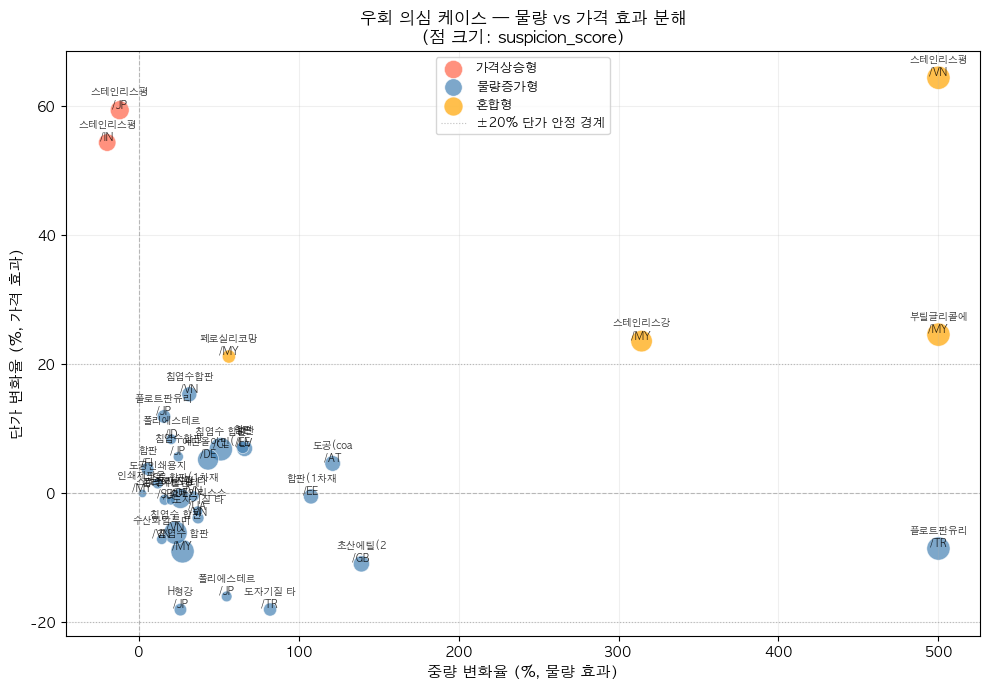

In [11]:
plot_df = result[result["type"].isin(["물량증가형", "혼합형", "가격상승형"])].copy()

# 시각화 범위 클리핑 (극단값 제거)
plot_df["wgt_pct_plot"]   = plot_df["wgt_pct"].clip(-200, 500)
plot_df["price_pct_plot"] = plot_df["price_pct"].clip(-100, 200)

palette = {"물량증가형": "steelblue", "혼합형": "orange", "가격상승형": "tomato"}

fig, ax = plt.subplots(figsize=(10, 7))

for t, grp in plot_df.groupby("type"):
    ax.scatter(
        grp["wgt_pct_plot"], grp["price_pct_plot"],
        s=grp["suspicion_score"].clip(0, 500) * 0.5 + 30,
        color=palette[t], alpha=0.7, label=t, edgecolors="white", linewidths=0.5,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            f"{row['product_name_kr'][:6]}\n/{row['intermediary_iso2']}",
            (row["wgt_pct_plot"], row["price_pct_plot"]),
            fontsize=7, ha="center", va="bottom", alpha=0.8,
        )

ax.axhline(0,  color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(20, color="gray", linestyle=":",  linewidth=0.8, alpha=0.5, label="±20% 단가 안정 경계")
ax.axhline(-20,color="gray", linestyle=":",  linewidth=0.8, alpha=0.5)
ax.axvline(0,  color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel("중량 변화율 (%, 물량 효과)", fontsize=11)
ax.set_ylabel("단가 변화율 (%, 가격 효과)", fontsize=11)
ax.set_title("우회 의심 케이스 — 물량 vs 가격 효과 분해\n(점 크기: suspicion_score)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8. 저장

In [12]:
result.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"저장 완료: {OUTPUT_PATH}")
print(f"총 {len(result)}건")
print()
print("유형 요약:")
print(result["type"].value_counts().to_string())

저장 완료: ../data/interim/price_volume_decomposition.csv
총 43건

유형 요약:
type
물량증가형         27
신규유입형          5
혼합형            4
기타             4
가격상승형          2
판정보류(중량결측)     1
